C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


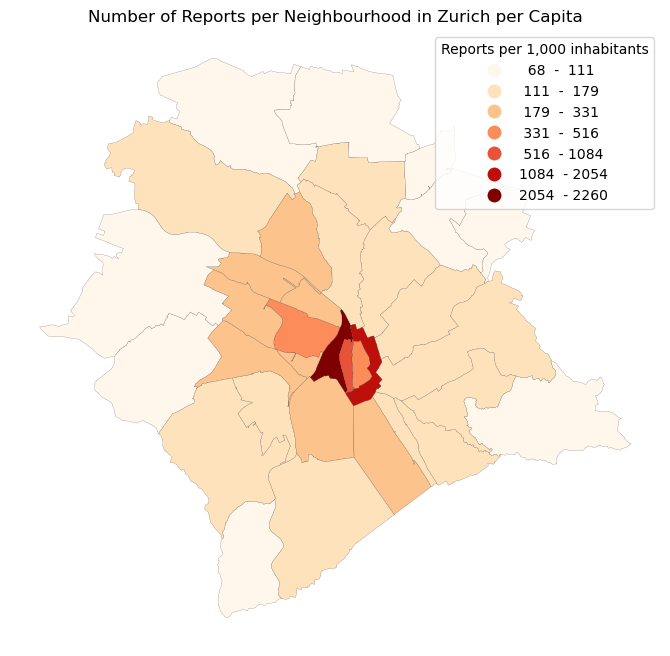

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NameError: name 'reports_per_capita' is not defined

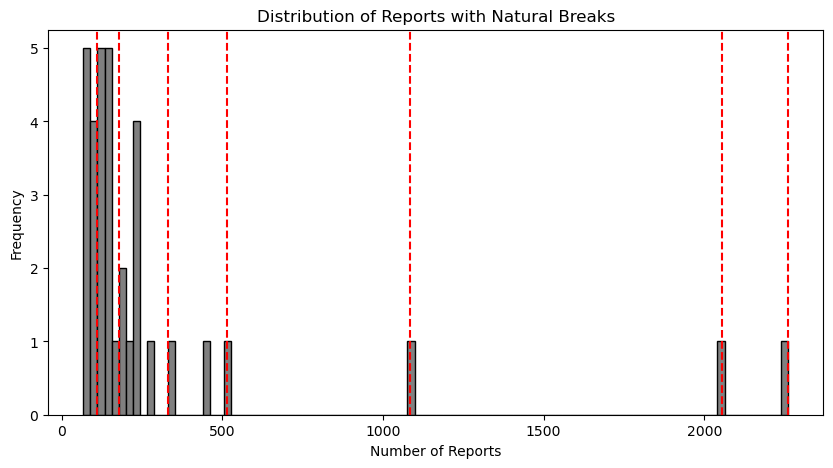

In [8]:
#load data zwn
import pandas as pd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#Clean data
#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n"]]

#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
}
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry"]]
processed_zwn.head((3))

# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

# load data populationsize
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
#clean and filter data
#choose year 2025
pop_size= raw_popsize[raw_popsize["StichtagDatJahr"]	== 2025]
#choose useful columns

pop_size = pop_size[["QuarLang","AnzBestWir"]]

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")
#pop_size.to_csv("../data/processed/pop_size.gpkg")

# Question 2: "Which neighbourhood receives the highest number of reports

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#count how many times a report has been submittet in a specific quartier 
count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")



#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
merge1 = processed_quartiere.merge(count, on="Quartier",how="left")#left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
merge2 = merge1.merge(pop_size, on="Quartier",how="left")

merge2["reports_per_capita"] = (merge2["count"]/merge2["PopSize"] *1000)


fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
merge2.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")



plt.show()
#plt.show()


#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

#histogram

import mapclassify

classifier = mapclassify.NaturalBreaks(merge2["reports_per_capita"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(merge2["reports_per_capita"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")
pop_size.head()









C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


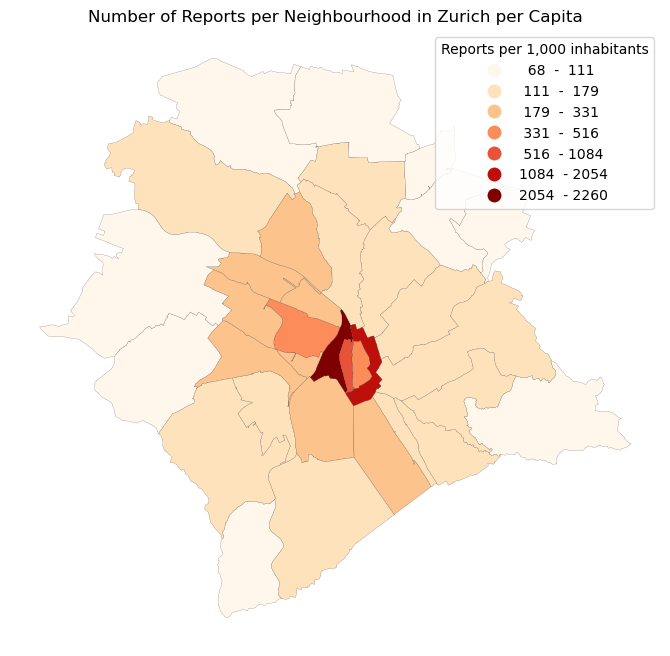

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Quartier,PopSize
0,Rathaus,3252
85,Hochschulen,688
170,Lindenhof,1038
255,City,769
340,Wollishofen,22029


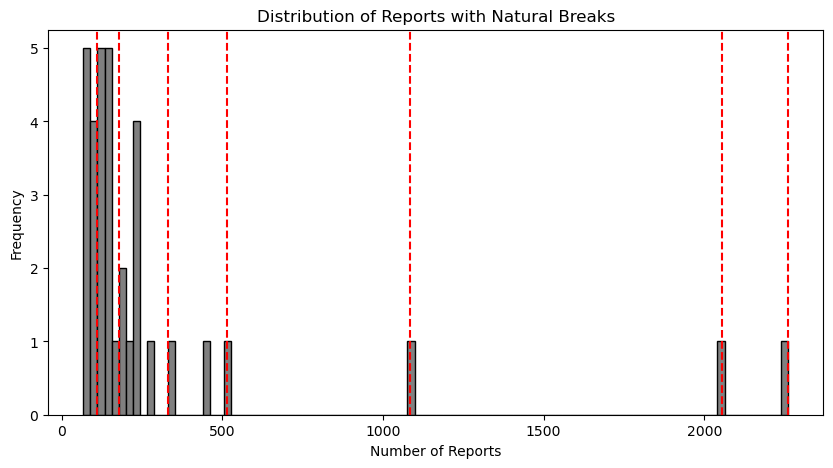

In [2]:
#load data zwn
import pandas as pd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#Clean data
#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n"]]

#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
}
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry"]]
processed_zwn.head((3))

# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

# load data populationsize
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
#clean and filter data
#choose year 2025
pop_size= raw_popsize[raw_popsize["StichtagDatJahr"]	== 2025]
#choose useful columns

pop_size = pop_size[["QuarLang","AnzBestWir"]]

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")
#pop_size.to_csv("../data/processed/pop_size.gpkg")

# Question 2: "Which neighbourhood receives the highest number of reports

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#count how many times a report has been submittet in a specific quartier 
count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")



#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
merge1 = processed_quartiere.merge(count, on="Quartier",how="left")#left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
merge2 = merge1.merge(pop_size, on="Quartier",how="left")

merge2["reports_per_capita"] = (merge2["count"]/merge2["PopSize"] *1000)


fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
merge2.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")



plt.show()
#plt.show()


#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

#histogram

import mapclassify

classifier = mapclassify.NaturalBreaks(merge2["reports_per_capita"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(merge2["reports_per_capita"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")
pop_size.head()


## Question 2: Which neighbourhood receives the highest number of reports ?

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


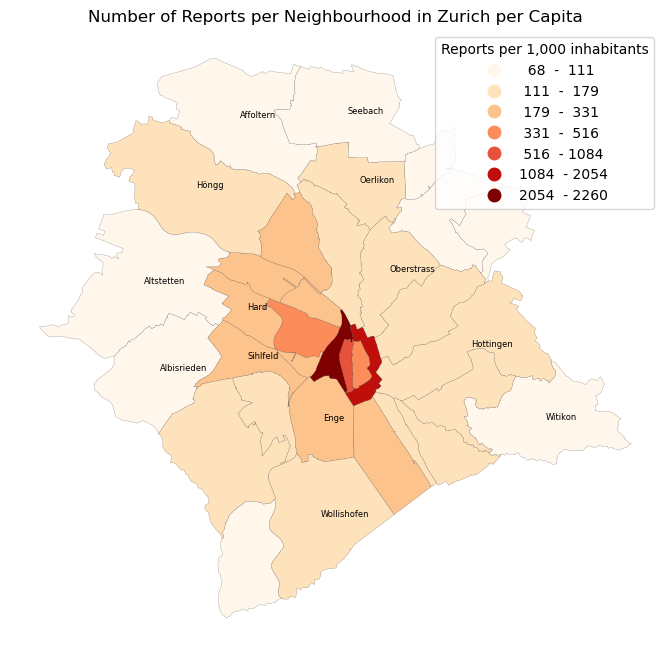

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


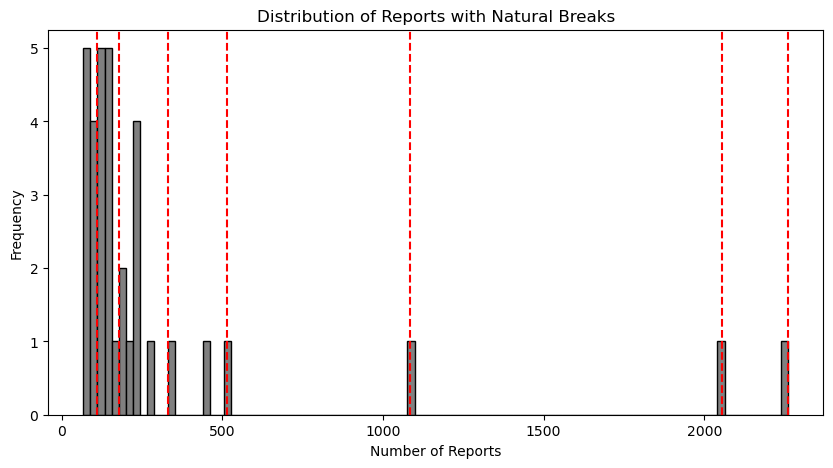

In [6]:
#------------------------------------------------------------------------------------------------
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")
#-------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# Data Analysis: 
#------------------------------------------------------------------------------------------------

count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")

reports_popsize = processed_quartiere.merge(count, on="Quartier",how="left")
reports_popsize = reports_popsize.merge(pop_size, on="Quartier",how="left")

reports_popsize["reports_per_capita"] = (reports_popsize["count"]/reports_popsize["PopSize"] *1000)

#----------------------------------------------------------------------------------------------
# Create Chlorpleth Map
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

reports_popsize.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
    
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =reports_popsize[reports_popsize["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)

plt.show()
#


#-------------------------------------------------------------------------------------------------
# Create histogram
#-------------------------------------------------------------------------------------------------

import mapclassify

classifier = mapclassify.NaturalBreaks(reports_popsize["reports_per_capita"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(reports_popsize["reports_per_capita"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")
plt.show()
